In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [35]:
df = pd.read_csv('../Mall_Customers.csv')

In [36]:
df.shape

(200, 5)

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


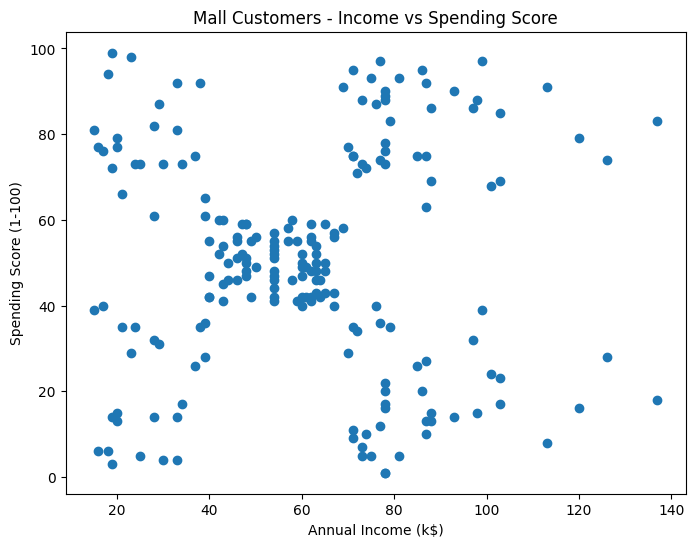

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)']
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Mall Customers - Income vs Spending Score')

plt.show()

In [39]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [40]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [41]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [42]:
from sklearn.cluster import AgglomerativeClustering
model=AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)
df['Agglomerative_Cluster'] = model.fit_predict(X)

print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Agglomerative_Cluster  
0                      4  
1                      3  
2                      4  
3                      3  
4                      4  


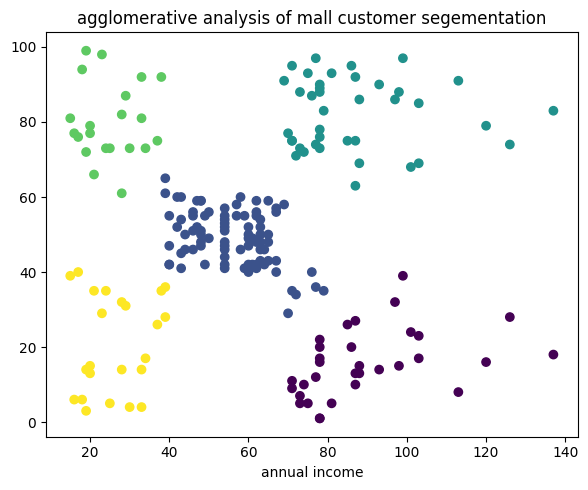

In [43]:
plt.figure(figsize=(6,5))
plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Agglomerative_Cluster']
)
plt.xlabel("annual income")
plt.title("agglomerative analysis of mall customer segementation")
plt.tight_layout()
plt.show()

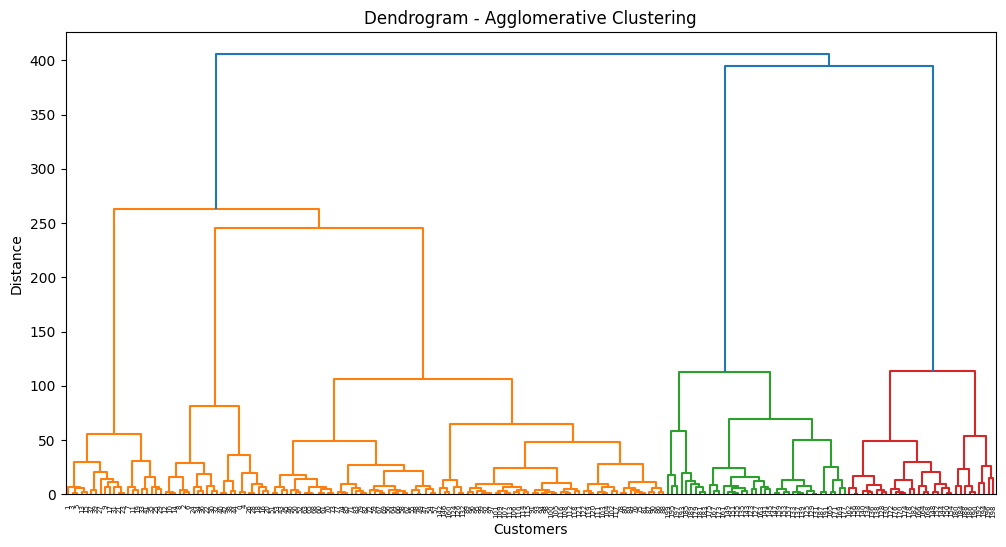

In [44]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X, method='ward')

plt.figure(figsize=(12, 6))

dendrogram(linked)

plt.title('Dendrogram - Agglomerative Clustering')
plt.xlabel('Customers')
plt.ylabel('Distance')
plt.show()

In [45]:
print(linked[:10])

[[ 65.  68.   0.   2.]
 [ 48.  49.   0.   2.]
 [156. 158.   0.   2.]
 [129. 131.   0.   2.]
 [ 21.  23.   1.   2.]
 [ 51.  53.   1.   2.]
 [ 60.  61.   1.   2.]
 [ 67.  69.   1.   2.]
 [ 64.  66.   1.   2.]
 [ 79.  82.   1.   2.]]


In [46]:
from sklearn.cluster import BisectingKMeans

In [47]:
model_b=BisectingKMeans(
    n_clusters=5,
    random_state=42
)

df['divsine cluster']=model_b.fit_predict(X)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Agglomerative_Cluster,divsine cluster
0,1,Male,19,15,39,4,2
1,2,Male,21,15,81,3,3
2,3,Female,20,16,6,4,2
3,4,Female,23,16,77,3,3
4,5,Female,31,17,40,4,2


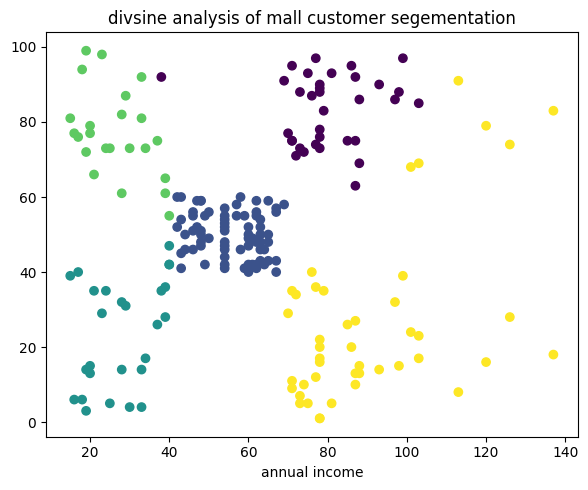

In [48]:
plt.figure(figsize=(6,5))
plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['divsine cluster']
)
plt.xlabel("annual income")
plt.title("divsine analysis of mall customer segementation")
plt.tight_layout()
plt.show()